# Feature Engineering

This notebook documents the feature-engineering layer used for stock return prediction.

The notebook covers:

1. feature sources and dataset loading  
2. feature family definitions  
3. comparison of the `daily` and `daily_ohlcv` datasets  
4. feature distributions and correlations  
5. final observations before model training  

The goal is to show how raw price and OHLCV data are transformed into model-ready stock-month observations.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config
from src.utils.paths import get_feature_dataset_paths
from src.utils.plotting import (
    STYLE,
    AUX_COLORS,
)

In [3]:
NOTEBOOK_NAME = "notebook02"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook02
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook02


In [4]:
def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> None:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Feature engineering context

Feature engineering is a central part of this project.

The prediction target is the **next-month stock return**, while the input variables are built from:

- adjusted close prices
- daily return history
- OHLCV data, where available

Two main feature sources are compared:

- **daily**: adjusted-close-based features
- **daily_ohlcv**: adjusted-close features plus OHLCV-derived features

In [5]:
daily_paths = get_feature_dataset_paths("daily")
daily_ohlcv_paths = get_feature_dataset_paths("daily_ohlcv")

daily_full = pd.read_parquet(PROJECT_ROOT / daily_paths["full"])
daily_train = pd.read_parquet(PROJECT_ROOT / daily_paths["train"])
daily_test = pd.read_parquet(PROJECT_ROOT / daily_paths["test"])

daily_ohlcv_full = pd.read_parquet(PROJECT_ROOT / daily_ohlcv_paths["full"])
daily_ohlcv_train = pd.read_parquet(PROJECT_ROOT / daily_ohlcv_paths["train"])
daily_ohlcv_test = pd.read_parquet(PROJECT_ROOT / daily_ohlcv_paths["test"])

In [6]:
dataset_overview = pd.DataFrame(
    {
        "dataset": [
            "daily_full",
            "daily_train",
            "daily_test",
            "daily_ohlcv_full",
            "daily_ohlcv_train",
            "daily_ohlcv_test",
        ],
        "shape": [
            daily_full.shape,
            daily_train.shape,
            daily_test.shape,
            daily_ohlcv_full.shape,
            daily_ohlcv_train.shape,
            daily_ohlcv_test.shape,
        ],
    }
)
dataset_overview

,dataset,shape
0,daily_full,"(11442, 16)"
1,daily_train,"(10418, 16)"
2,daily_test,"(1024, 16)"
3,daily_ohlcv_full,"(11398, 24)"
4,daily_ohlcv_train,"(10374, 24)"
5,daily_ohlcv_test,"(1024, 24)"


In [7]:
daily_target_cols = [c for c in daily_full.columns if c.startswith("y_next")]
daily_ohlcv_target_cols = [c for c in daily_ohlcv_full.columns if c.startswith("y_next")]

daily_target_col = daily_target_cols[0]
daily_ohlcv_target_col = daily_ohlcv_target_cols[0]

daily_feature_cols = [c for c in daily_full.columns if c != daily_target_col]
daily_ohlcv_feature_cols = [c for c in daily_ohlcv_full.columns if c != daily_ohlcv_target_col]

print("daily target:", daily_target_col)
print("daily_ohlcv target:", daily_ohlcv_target_col)
print("daily n_features:", len(daily_feature_cols))
print("daily_ohlcv n_features:", len(daily_ohlcv_feature_cols))

daily target: y_next_1m
daily_ohlcv target: y_next_1m
daily n_features: 15
daily_ohlcv n_features: 23


In [8]:
feature_lists = pd.DataFrame(
    {
        "daily_features": pd.Series(daily_feature_cols),
        "daily_ohlcv_features": pd.Series(daily_ohlcv_feature_cols),
    }
)
feature_lists

,daily_features,daily_ohlcv_features
0,ret_5d,ret_5d
1,ret_20d,ret_20d
2,ret_60d,ret_60d
3,ret_120d,ret_120d
4,ret_252d,ret_252d
5,vol_20d,vol_20d
6,vol_60d,vol_60d
7,vol_120d,vol_120d
8,ma_ratio_20_60,ma_ratio_20_60
9,ma_ratio_60_252,ma_ratio_60_252


## 2. Feature families

The feature sets contain several distinct families:

- **return features**: rolling returns over different windows
- **volatility features**: rolling standard deviation of returns
- **trend features**: moving-average ratios
- **drawdown / distance features**: distance from recent highs
- **momentum oscillator features**: RSI
- **spread features**: differences between short and medium return windows
- **OHLCV features**: volume, abnormal volume, intraday range, close-location value, and open-close return

These feature families are designed to capture different aspects of price behavior, momentum, reversal, liquidity, and market microstructure.

In [9]:
def classify_feature_family(feature_name: str) -> str:
    if feature_name.startswith("ret_spread_"):
        return "return_spread"
    if feature_name.startswith("ret_"):
        return "return"
    if feature_name.startswith("vol_"):
        return "volatility"
    if feature_name.startswith("ma_ratio_"):
        return "moving_average_ratio"
    if feature_name.startswith("dist_"):
        return "distance_from_high"
    if feature_name.startswith("drawdown_"):
        return "drawdown"
    if feature_name.startswith("rsi_"):
        return "rsi"
    if feature_name.startswith("excess_ret_"):
        return "excess_return"
    if feature_name.startswith("beta_"):
        return "beta"
    if feature_name.startswith("volavg_"):
        return "volume_average"
    if feature_name.startswith("abvol_"):
        return "abnormal_volume"
    if feature_name.startswith("range_"):
        return "intraday_range"
    if feature_name.startswith("clv_"):
        return "close_location_value"
    if feature_name == "open_close_ret":
        return "open_close_return"
    return "other"


daily_family_df = pd.DataFrame({"feature": daily_feature_cols})
daily_family_df["family"] = daily_family_df["feature"].apply(classify_feature_family)

daily_ohlcv_family_df = pd.DataFrame({"feature": daily_ohlcv_feature_cols})
daily_ohlcv_family_df["family"] = daily_ohlcv_family_df["feature"].apply(classify_feature_family)

In [10]:
daily_family_counts = daily_family_df["family"].value_counts().sort_index()
daily_ohlcv_family_counts = daily_ohlcv_family_df["family"].value_counts().sort_index()

family_count_table = pd.DataFrame(
    {
        "daily": daily_family_counts,
        "daily_ohlcv": daily_ohlcv_family_counts,
    }
).fillna(0).astype(int)

family_count_table

,daily,daily_ohlcv
family,,
abnormal_volume,0,1
close_location_value,0,2
distance_from_high,1,1
drawdown,1,1
intraday_range,0,2
moving_average_ratio,2,2
open_close_return,0,1
return,5,5
return_spread,2,2


In [11]:
save_table(feature_lists, "feature_lists_daily_vs_daily_ohlcv.csv", index=False)
save_table(family_count_table.reset_index().rename(columns={"index": "family"}), "feature_family_counts.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook02\feature_lists_daily_vs_daily_ohlcv.csv
Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook02\feature_family_counts.csv


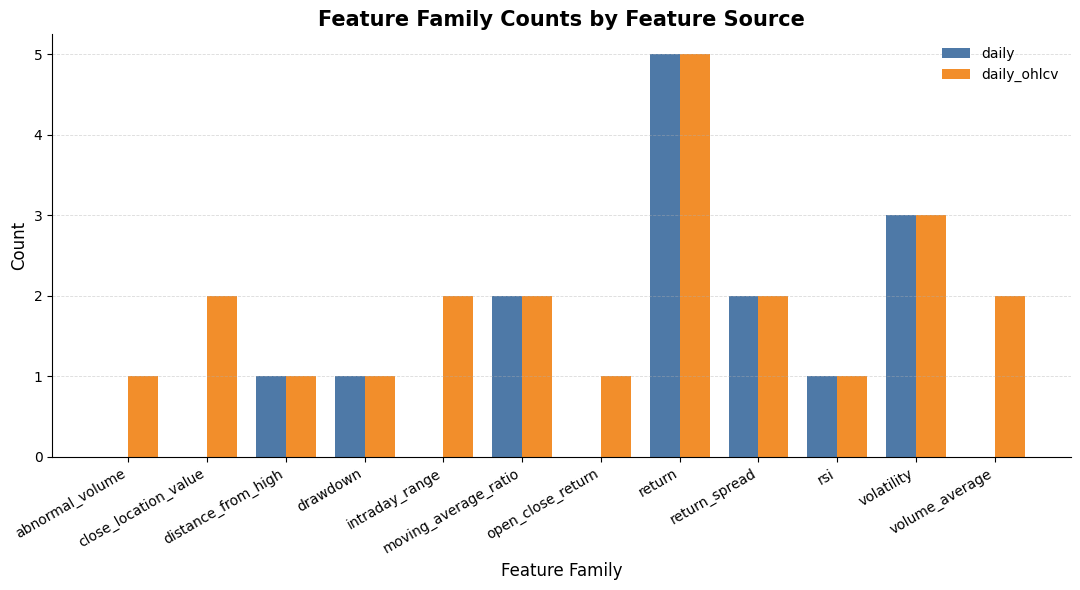

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_df = family_count_table.copy()
x = np.arange(len(plot_df.index))
width = 0.38

ax.bar(x - width/2, plot_df["daily"], width=width, label="daily", color="#4E79A7")
ax.bar(x + width/2, plot_df["daily_ohlcv"], width=width, label="daily_ohlcv", color="#F28E2B")

ax.set_title("Feature Family Counts by Feature Source", fontsize=STYLE.title_size, fontweight="bold")
ax.set_xlabel("Feature Family", fontsize=STYLE.label_size)
ax.set_ylabel("Count", fontsize=STYLE.label_size)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax.grid(True, axis="y", linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
ax.tick_params(axis="both", labelsize=STYLE.tick_size)
ax.legend(frameon=False, fontsize=STYLE.legend_size, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(fig_path("feature_family_counts.png"), dpi=STYLE.dpi, bbox_inches="tight")
plt.show()

## 3. Daily vs daily_ohlcv comparison

The `daily` feature set is based on adjusted-close-derived signals.

The `daily_ohlcv` feature set extends this with additional OHLCV-derived information, including:

- rolling average volume
- abnormal volume
- intraday range
- close-location value
- open-close return

The next step is to compare the resulting datasets in terms of size and structure.

In [13]:
comparison_table = pd.DataFrame(
    {
        "feature_source": ["daily", "daily_ohlcv"],
        "n_features": [len(daily_feature_cols), len(daily_ohlcv_feature_cols)],
        "full_rows": [daily_full.shape[0], daily_ohlcv_full.shape[0]],
        "train_rows": [daily_train.shape[0], daily_ohlcv_train.shape[0]],
        "test_rows": [daily_test.shape[0], daily_ohlcv_test.shape[0]],
        "target_col": [daily_target_col, daily_ohlcv_target_col],
    }
)
comparison_table

,feature_source,n_features,full_rows,train_rows,test_rows,target_col
0,daily,15,11442,10418,1024,y_next_1m
1,daily_ohlcv,23,11398,10374,1024,y_next_1m


In [14]:
save_table(comparison_table, "daily_vs_daily_ohlcv_dataset_comparison.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook02\daily_vs_daily_ohlcv_dataset_comparison.csv


In [15]:
daily_ohlcv_full.head()

ret_5d   ret_20d   ret_60d  ret_120d  ret_252d   vol_20d  \
date       ticker                                                               
2015-12-31 AAL.L   0.009949 -0.262983 -0.504386 -0.658915 -0.747123  0.049158   
           ABF.L   0.026098 -0.056931 -0.025587  0.066105  0.046446  0.015650   
           ADM.L   0.019668  0.012203  0.092166  0.127394  0.262395  0.011036   
           ALW.L   0.017717  0.008859  0.065622  0.048609  0.085298  0.010913   
           ANTO.L  0.054607 -0.084293 -0.126071 -0.296378 -0.372519  0.028544   

                    vol_60d  vol_120d  ma_ratio_20_60  ma_ratio_60_252  ...  \
date       ticker                                                       ...   
2015-12-31 AAL.L   0.043915  0.040751       -0.324856        -0.449872  ...   
           ABF.L   0.012495  0.013514       -0.002891         0.089360  ...   
           ADM.L   0.010578  0.014910        0.012244         0.066773  ...   
           ALW.L   0.008067  0.011076        0.008688         0.012225  ...   
           ANTO.L  0.027058  0.029450       -0.105142        -0.212184  ...   

                   ret_spread_20d_60d   volavg_20d    volavg_60d  abvol_20d  \
date       ticker                                                             
2015-12-31 AAL.L             0.241403  13598176.10  1.199638e+07  -0.871847   
           ABF.L            -0.031344    614220.45  6.221348e+05  -0.822653   
           ADM.L            -0.079963    532161.05  7.465456e+05  -0.734047   
           ALW.L            -0.056764    520902.40  6.554835e+05  -0.639840   
           ANTO.L            0.041778   2859858.45  3.360258e+06  -0.801276   

                   range_5d  range_20d    clv_5d   clv_20d  open_close_ret  \
date       ticker                                                            
2015-12-31 AAL.L   0.049693   0.074723 -0.005382 -0.146518       -0.006470   
           ABF.L   0.012785   0.017982  0.108651 -0.136795       -0.012119   
           ADM.L   0.015974   0.015756  0.175003 -0.075067       -0.001805   
           ALW.L   0.008184   0.013685  0.261503  0.080172        0.000000   
           ANTO.L  0.026972   0.040112  0.191546 -0.086061        0.005140   

                   y_next_1m  
date       ticker             
2015-12-31 AAL.L   -0.073468  
           ABF.L   -0.057451  
           ADM.L    0.069319  
           ALW.L   -0.052805  
           ANTO.L  -0.189857  

[5 rows x 24 columns]

In [16]:
feature_description_rows = [
    ("ret_5d / ret_20d / ret_60d / ...", "Rolling return over a given lookback window"),
    ("vol_20d / vol_60d / ...", "Rolling standard deviation of daily returns"),
    ("ma_ratio_20_60 / ma_ratio_60_252", "Relative position of short and long moving averages"),
    ("dist_252d_high", "Distance from rolling 252-day high"),
    ("drawdown_60d", "Recent drawdown proxy"),
    ("rsi_14d", "Momentum oscillator based on recent gains and losses"),
    ("ret_spread_5d_20d", "Short-minus-medium return spread"),
    ("ret_spread_20d_60d", "Medium-minus-long return spread"),
    ("volavg_20d / volavg_60d", "Rolling average traded volume"),
    ("abvol_20d", "Current volume relative to recent volume average"),
    ("range_5d / range_20d", "Average high-low range scaled by price"),
    ("clv_5d / clv_20d", "Rolling close-location value"),
    ("open_close_ret", "Open-to-close return"),
]

feature_description_table = pd.DataFrame(feature_description_rows, columns=["feature_group", "interpretation"])
feature_description_table

,feature_group,interpretation
0,ret_5d / ret_20d / ret_60d / ...,Rolling return over a given lookback window
1,vol_20d / vol_60d / ...,Rolling standard deviation of daily returns
2,ma_ratio_20_60 / ma_ratio_60_252,Relative position of short and long moving ave...
3,dist_252d_high,Distance from rolling 252-day high
4,drawdown_60d,Recent drawdown proxy
5,rsi_14d,Momentum oscillator based on recent gains and ...
6,ret_spread_5d_20d,Short-minus-medium return spread
7,ret_spread_20d_60d,Medium-minus-long return spread
8,volavg_20d / volavg_60d,Rolling average traded volume
9,abvol_20d,Current volume relative to recent volume average


In [17]:
save_table(feature_description_table, "feature_description_table.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook02\feature_description_table.csv


## 4. Feature distributions

Selected feature distributions are inspected below.

The objective is not to inspect every variable individually, but to verify that:

- scales look reasonable
- distributions are not obviously broken
- OHLCV-derived features add distinct information

In [18]:
example_features = [
    "ret_20d",
    "vol_20d",
    "ma_ratio_20_60",
    "ret_spread_5d_20d",
    "abvol_20d",
    "range_20d",
    "clv_20d",
    "open_close_ret",
]

available_example_features = [f for f in example_features if f in daily_ohlcv_full.columns]
available_example_features

['ret_20d',
 'vol_20d',
 'ma_ratio_20_60',
 'ret_spread_5d_20d',
 'abvol_20d',
 'range_20d',
 'clv_20d',
 'open_close_ret']

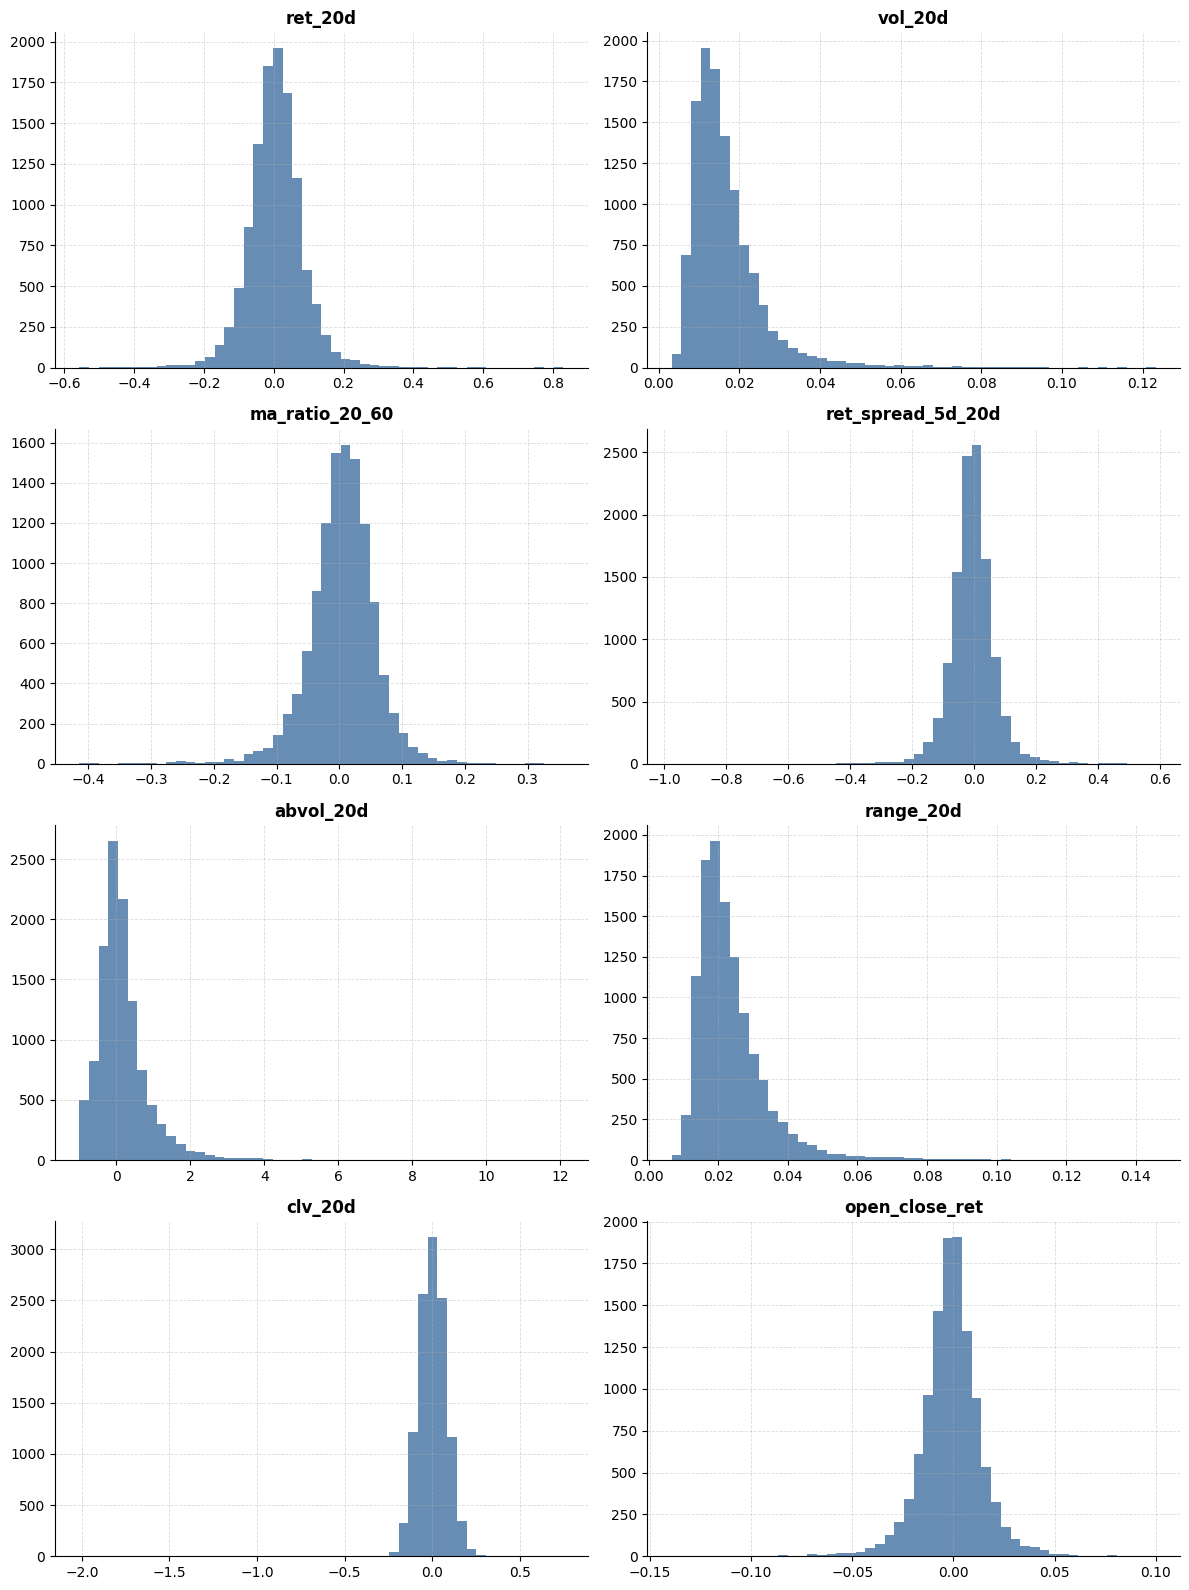

In [19]:
n_cols = 2
n_rows = int(np.ceil(len(available_example_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, available_example_features):
    vals = daily_ohlcv_full[feature].dropna().values
    ax.hist(vals, bins=50, color=AUX_COLORS["hist"], alpha=STYLE.hist_alpha)
    ax.set_title(feature, fontsize=STYLE.label_size, fontweight="bold")
    ax.grid(True, linestyle=STYLE.grid_linestyle, linewidth=STYLE.grid_linewidth, alpha=STYLE.grid_alpha)
    ax.tick_params(axis="both", labelsize=STYLE.tick_size)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(available_example_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(fig_path("selected_feature_histograms_daily_ohlcv.png"), dpi=STYLE.dpi, bbox_inches="tight")
plt.show()

## 5. Selected feature correlation analysis

A subset of features is used to inspect broad correlation patterns.

This helps identify whether some variables are highly redundant and whether different feature families capture distinct information.

In [20]:
corr_features = [f for f in available_example_features if f in daily_ohlcv_full.columns]
corr_df = daily_ohlcv_full[corr_features].dropna().corr()

corr_df

,ret_20d,vol_20d,ma_ratio_20_60,ret_spread_5d_20d,abvol_20d,range_20d,clv_20d,open_close_ret
ret_20d,1.000000,-0.112156,0.506962,-0.862987,-0.009468,-0.128972,0.534737,0.108701
vol_20d,-0.112156,1.000000,-0.278297,0.139730,0.001741,0.861930,-0.091274,-0.057638
ma_ratio_20_60,0.506962,-0.278297,1.000000,-0.586056,0.022997,-0.297749,0.322138,-0.004400
ret_spread_5d_20d,-0.862987,0.139730,-0.586056,1.000000,-0.042669,0.167600,-0.460460,0.029529
abvol_20d,-0.009468,0.001741,0.022997,-0.042669,1.000000,-0.020681,0.020213,-0.021310
range_20d,-0.128972,0.861930,-0.297749,0.167600,-0.020681,1.000000,-0.098862,-0.060149
clv_20d,0.534737,-0.091274,0.322138,-0.460460,0.020213,-0.098862,1.000000,0.166804
open_close_ret,0.108701,-0.057638,-0.004400,0.029529,-0.021310,-0.060149,0.166804,1.000000


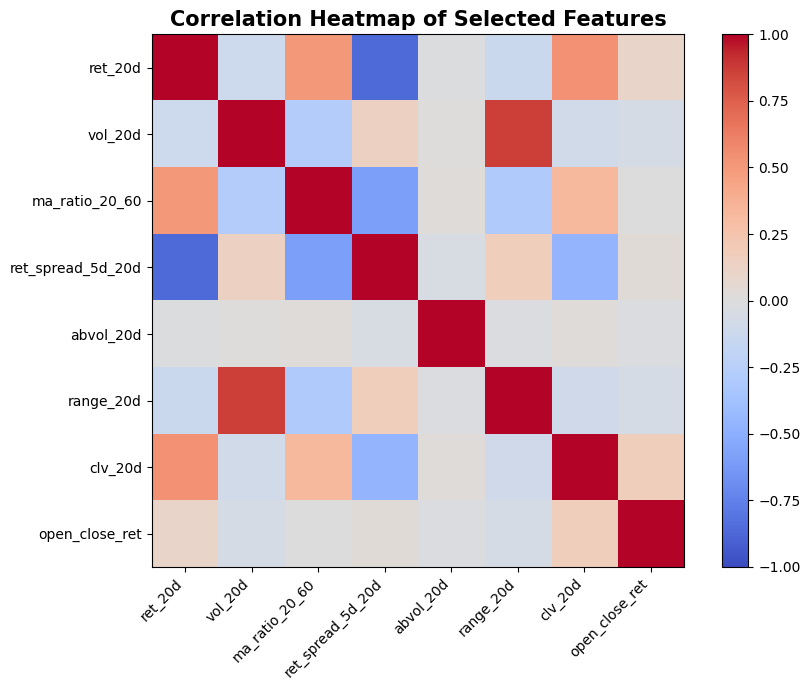

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_df.columns)))
ax.set_yticks(np.arange(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_df.index)

ax.set_title("Correlation Heatmap of Selected Features", fontsize=STYLE.title_size, fontweight="bold")
ax.tick_params(axis="both", labelsize=STYLE.tick_size)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=STYLE.tick_size)

plt.tight_layout()
plt.savefig(fig_path("selected_feature_correlation_heatmap.png"), dpi=STYLE.dpi, bbox_inches="tight")
plt.show()

In [22]:
train_test_overview = pd.DataFrame(
    {
        "feature_source": ["daily", "daily_ohlcv"],
        "train_rows": [daily_train.shape[0], daily_ohlcv_train.shape[0]],
        "test_rows": [daily_test.shape[0], daily_ohlcv_test.shape[0]],
        "n_train_features": [len(daily_feature_cols), len(daily_ohlcv_feature_cols)],
        "n_test_features": [len(daily_feature_cols), len(daily_ohlcv_feature_cols)],
    }
)
train_test_overview

,feature_source,train_rows,test_rows,n_train_features,n_test_features
0,daily,10418,1024,15,15
1,daily_ohlcv,10374,1024,23,23


In [23]:
save_table(train_test_overview, "train_test_feature_overview.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook02\train_test_feature_overview.csv


## 6. Interpretation of feature evolution

The feature-engineering process evolved in stages:

1. adjusted-close-based daily features  
2. spread features to capture momentum slope and reversal structure  
3. OHLCV-derived features to capture volume and intraday behavior  

The extended `daily_ohlcv` dataset provides a richer description of each stock-month observation while preserving the same target definition.

## 7. Key findings

The feature-engineering layer leads to the following conclusions:

- the `daily` dataset captures medium-horizon trend and volatility information
- spread features add explicit momentum-shape information
- the `daily_ohlcv` dataset extends the feature space with volume and intraday structure
- the OHLCV extension increases the number of available predictors without changing the prediction target
- the resulting datasets are suitable for fair comparison across linear, tree-based, and neural models